# STL Schritt für Schritt im CRISP-DM-Prozess

Dieses Notebook erklärt die **STL-Zerlegung** didaktisch und Schritt für Schritt.

STL steht für **Seasonal and Trend decomposition using LOESS**. Die Methode zerlegt eine Zeitreihe in drei Bestandteile:

\[
y_t = T_t + S_t + R_t
\]

- \(T_t\): Trend, also die langfristige Entwicklung
- \(S_t\): saisonaler Effekt, also ein wiederkehrendes Muster
- \(R_t\): Residuum, also der nicht erklärte Rest

Die Reihenfolge orientiert sich am **CRISP-DM-Modell**:

1. Geschäftsverständnis
2. Datenverständnis
3. Datenvorbereitung
4. Modeling
5. Evaluation
6. Deployment

Wichtig: CRISP-DM ist kein einmaliger Durchlauf. Feedback aus der Evaluation oder aus dem Fachbereich kann dazu führen, dass wir eine weitere Iteration starten und Annahmen, Daten oder Modellierung anpassen.

## 1. Geschäftsverständnis

Wir stellen uns ein Unternehmen vor, das monatliche Nachfragewerte analysieren möchte.

Die fachlichen Fragen lauten:

- Wächst die Nachfrage langfristig?
- Gibt es ein stabiles saisonales Muster?
- Welche Monate sind ungewöhnlich und sollten fachlich geprüft werden?
- Ist ein additives Modell ausreichend, oder wächst die Saisonalität mit dem Niveau der Zeitreihe?

STL hilft hier nicht direkt als Prognosemodell, sondern als **Erklärungs- und Vorverarbeitungsschritt**. Es macht sichtbar, welche Struktur in der Zeitreihe steckt.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

rng = np.random.default_rng(42)

## 2. Datenverständnis

Für die Erklärung verwenden wir zuerst eine kuenstliche monatliche Zeitreihe.

Der Vorteil: Wir kennen die ungefähre Struktur der Daten. Dadurch kann man besser sehen, was STL rekonstruiert:

- ein langsam steigender Trend
- ein jährliches saisonales Muster
- zufällige Schwankungen
- einzelne Ausreißer

Die Ausreißer sind absichtlich eingebaut, damit später der Unterschied zwischen **Standard-STL** und **robuste STL** sichtbar wird.

In [28]:
dates = pd.date_range("2018-01-01", periods=72, freq="MS")
t = np.arange(len(dates))

trend = 120 + 1.4 * t
seasonal_pattern = np.array([-18, -12, 4, 10, 14, 22, 30, 26, 12, 2, -10, -20])
seasonal = np.tile(seasonal_pattern, len(dates) // 12)
noise = rng.normal(0, 5, size=len(dates))

sales = trend + seasonal + noise
sales[[22, 45]] += [55, -48]

ts = pd.Series(sales, index=dates, name="nachfrage")
ts.head()

2018-01-01    103.523585
2018-02-01    104.200079
2018-03-01    130.552256
2018-04-01    138.902824
2018-05-01    129.844824
Freq: MS, Name: nachfrage, dtype: float64

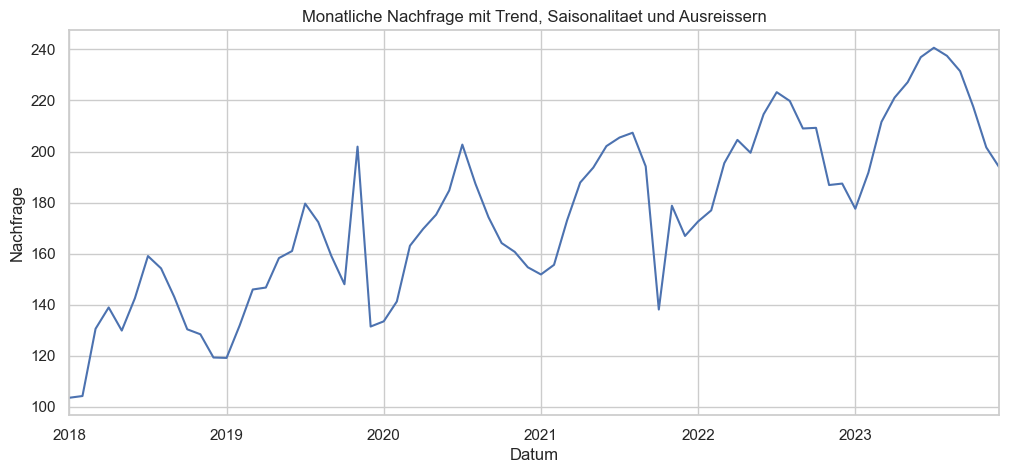

In [29]:
ax = ts.plot(title="Monatliche Nachfrage mit Trend, Saisonalitaet und Ausreissern")
ax.set_xlabel("Datum")
ax.set_ylabel("Nachfrage")
plt.show()

### Erste Beobachtung

Schon vor der Modellierung erkennt man drei Dinge:

- Die Reihe steigt langfristig.
- Das Muster wiederholt sich ungefähr alle 12 Monate.
- Einige Punkte wirken ungewöhnlich hoch oder niedrig.

Diese Beobachtungen führen direkt zur Wahl von `period=12`, weil die Daten monatlich sind und ein Jahr aus 12 Monaten besteht.

## 3. Datenvorbereitung

STL erwartet eine geordnete Zeitreihe mit regelmäßiger Frequenz.

In echten Projekten würde man hier fehlende Werte, doppelte Zeitpunkte, Ausreißer, Kalendereffekte und Aggregationslogik pruefen. In diesem Beispiel sind die Daten bereits monatlich und vollständig.

In [30]:
pruefung = pd.DataFrame({
    "anzahl_werte": [ts.shape[0]],
    "fehlende_werte": [ts.isna().sum()],
    "start": [ts.index.min()],
    "ende": [ts.index.max()],
    "frequenz": [pd.infer_freq(ts.index)],
})

pruefung

,anzahl_werte,fehlende_werte,start,ende,frequenz
0,72,0,2018-01-01,2023-12-01,MS


## 4. Modellierung: Standard-STL

Jetzt wenden wir STL an.

Die wichtigsten Einstellungen sind:

- `period=12`: Das saisonale Muster wiederholt sich alle 12 Monate.
- `robust=False`: Standard-STL behandelt alle Beobachtungen gleich, auch Ausreißer.

Das Ergebnis besteht aus beobachteter Reihe, Trend, Saison und Residuum.

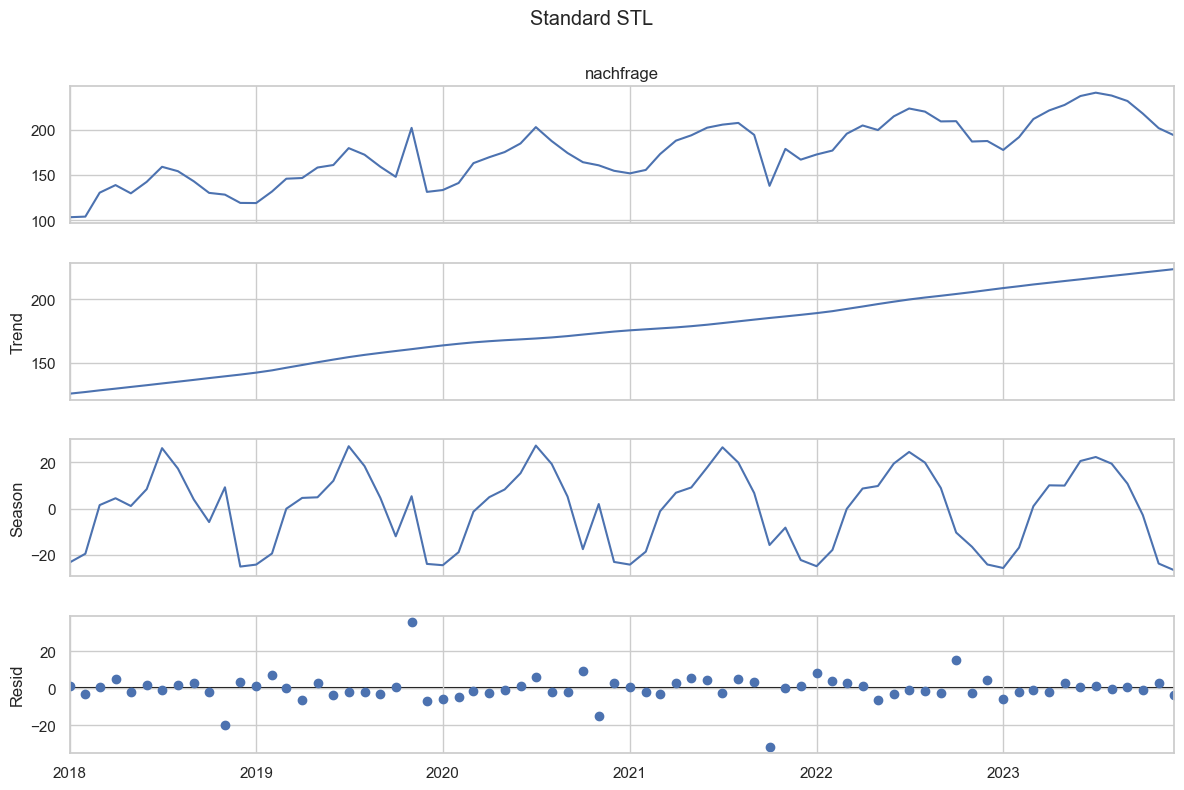

In [31]:
standard_result = STL(ts, period=12, robust=False).fit()

fig = standard_result.plot()
fig.set_size_inches(12, 8)
plt.suptitle("Standard STL", y=1.02)
plt.show()

In [32]:
standard_components = pd.DataFrame({
    "beobachtet": ts,
    "trend": standard_result.trend,
    "saisonal": standard_result.seasonal,
    "residuum": standard_result.resid,
})

standard_components.head(15)

,beobachtet,trend,saisonal,residuum
2018-01-01,103.523585,125.531882,-23.306340,1.298044
2018-02-01,104.200079,126.844248,-19.504390,-3.139778
2018-03-01,130.552256,128.166174,1.516876,0.869206
2018-04-01,138.902824,129.500818,4.470800,4.931205
2018-05-01,129.844824,130.851123,1.124192,-2.130490
2018-06-01,142.489102,132.217938,8.411047,1.860117
2018-07-01,159.039202,133.601749,26.114851,-0.677398
2018-08-01,154.218787,135.001562,17.308556,1.908669
2018-09-01,143.115994,136.414220,3.950876,2.750898
2018-10-01,130.334780,137.830827,-5.816602,-1.679444


### Komponenten lesen

Die Zerlegung ist eine additive Rekonstruktion:

\[
beobachtet \approx trend + saisonal + residuum
\]

Der Trend beschreibt die langsame Grundbewegung. Die saisonale Komponente beschreibt typische Monatsabweichungen. Das Residuum zeigt, was nach Trend und Saison übrig bleibt.

In [33]:
rekonstruktion = standard_components["trend"] + standard_components["saisonal"] + standard_components["residuum"]
maximaler_fehler = (standard_components["beobachtet"] - rekonstruktion).abs().max()

print(f"Maximaler Rekonstruktionsfehler: {maximaler_fehler:.10f}")

Maximaler Rekonstruktionsfehler: 0.0000000000


## 5. Evaluation

In CRISP-DM prüfen wir jetzt, ob die Zerlegung fachlich sinnvoll ist.

Typische Fragen:

- Ist der Trend plausibel glatt?
- Ist die Saison stabil und interpretierbar?
- Sind große Residuen fachlich erklärbar?
- Stören Ausreißer die Trend- oder Saisonkomponente?

Diese Evaluation ist bewusst nicht nur technisch. Sie sollte mit Feedback aus dem Fachbereich verbunden werden.

In [34]:
residuen = standard_components["residuum"]
grenze = 2 * residuen.std()

auffaellig = standard_components.loc[residuen.abs() > grenze, ["beobachtet", "trend", "saisonal", "residuum"]]
auffaellig

,beobachtet,trend,saisonal,residuum
2018-11-01,128.396990,139.230748,9.201858,-20.035615
2019-11-01,201.912707,160.665037,5.336931,35.910739
2021-10-01,138.093443,185.258595,-15.731576,-31.433576
2022-10-01,209.274707,204.188911,-10.352528,15.438324


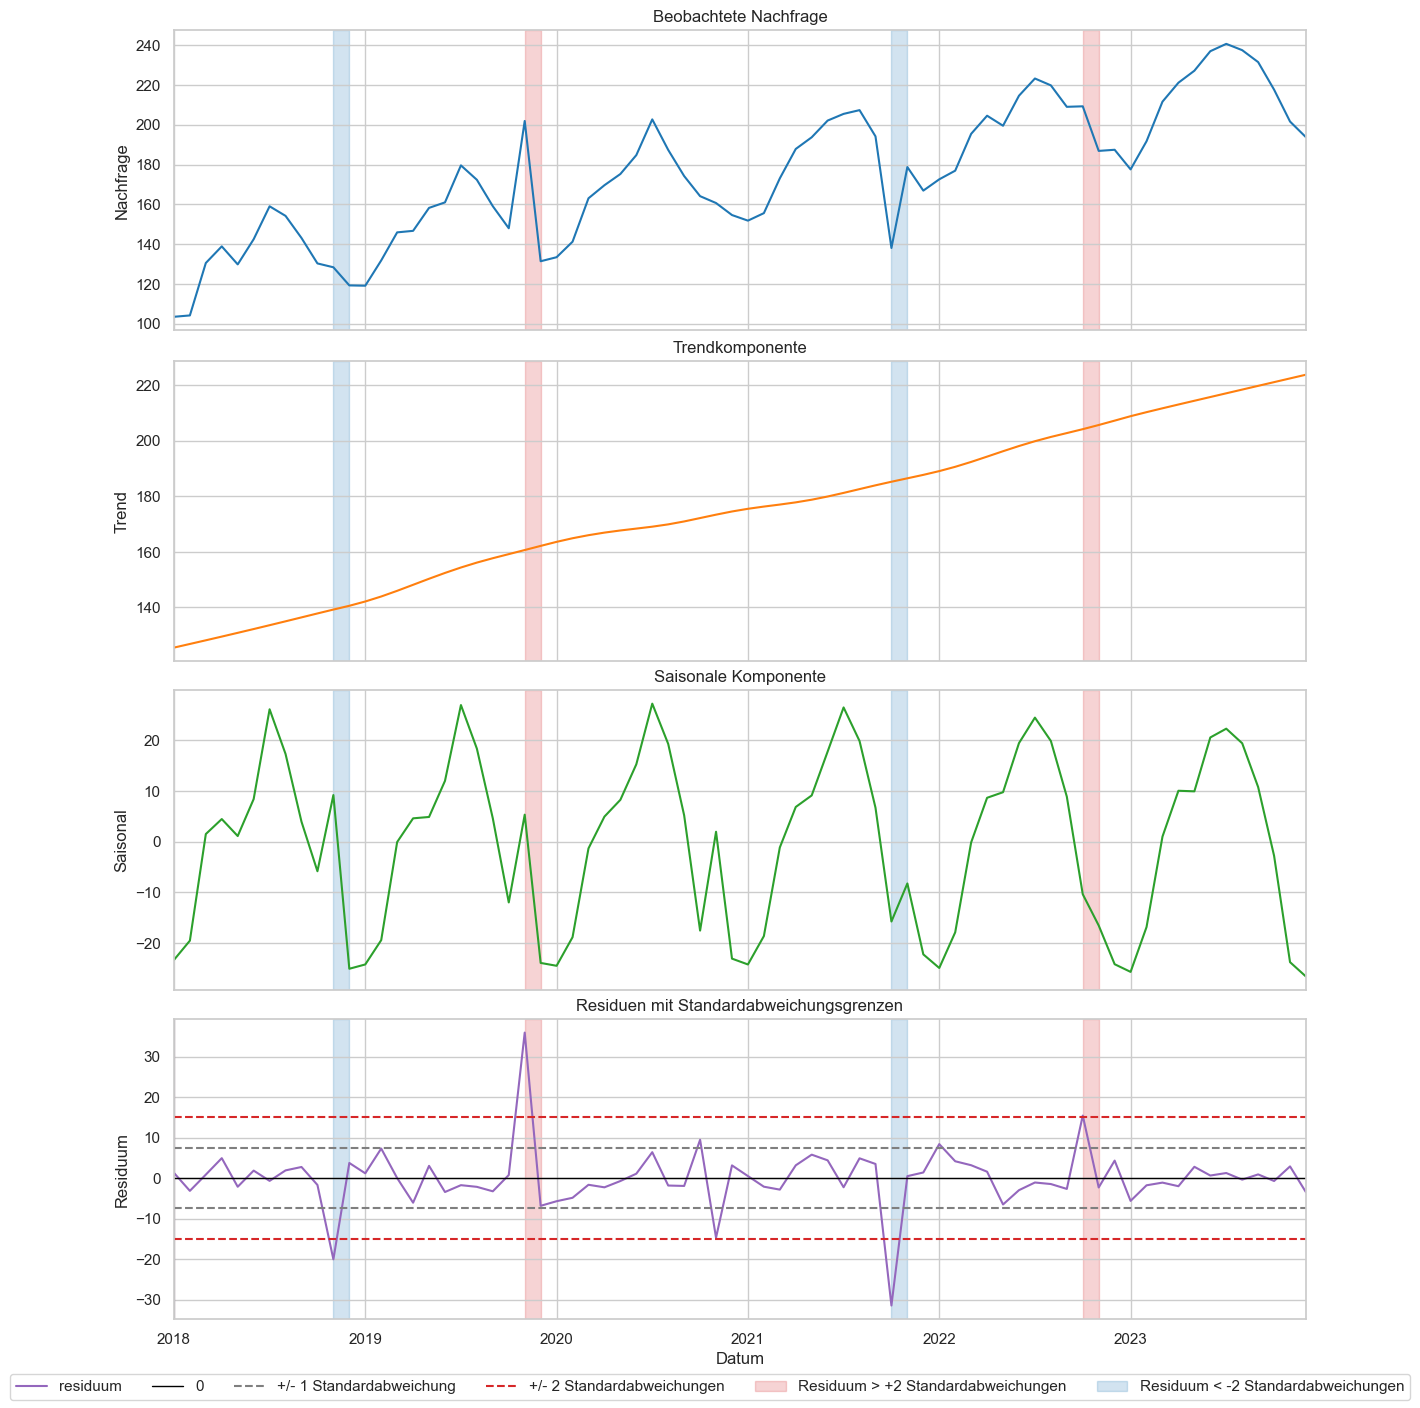

In [35]:
residuen = standard_components["residuum"]
residuen_std = residuen.std()
grenze = 2 * residuen_std

positive_spikes = residuen > grenze
negative_spikes = residuen < -grenze
month_offset = pd.DateOffset(months=1)

fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True, constrained_layout=True)

standard_components["beobachtet"].plot(ax=axes[0], color="tab:blue", title="Beobachtete Nachfrage")
axes[0].set_ylabel("Nachfrage")

standard_components["trend"].plot(ax=axes[1], color="tab:orange", title="Trendkomponente")
axes[1].set_ylabel("Trend")

standard_components["saisonal"].plot(ax=axes[2], color="tab:green", title="Saisonale Komponente")
axes[2].set_ylabel("Saisonal")

residuen.plot(ax=axes[3], color="tab:purple", title="Residuen mit Standardabweichungsgrenzen")
axes[3].axhline(0, linestyle="-", color="black", linewidth=1, label="0")
axes[3].axhline(residuen_std, linestyle="--", color="tab:gray", label="+/- 1 Standardabweichung")
axes[3].axhline(-residuen_std, linestyle="--", color="tab:gray")
axes[3].axhline(grenze, linestyle="--", color="tab:red", label="+/- 2 Standardabweichungen")
axes[3].axhline(-grenze, linestyle="--", color="tab:red")
axes[3].set_xlabel("Datum")
axes[3].set_ylabel("Residuum")

# Shade the full calendar month on every subplot where residuum exceeds the threshold.
for ax in axes:
    for date in residuen.index[positive_spikes]:
        ax.axvspan(date, date + month_offset, color="tab:red", alpha=0.2, zorder=0)
    for date in residuen.index[negative_spikes]:
        ax.axvspan(date, date + month_offset, color="tab:blue", alpha=0.2, zorder=0)

# Invisible zero-width spans just to add shading entries to the legend.
axes[3].axvspan(residuen.index[0], residuen.index[0], color="tab:red", alpha=0.2, label="Residuum > +2 Standardabweichungen")
axes[3].axvspan(residuen.index[0], residuen.index[0], color="tab:blue", alpha=0.2, label="Residuum < -2 Standardabweichungen")

# Place a single legend below all subplots.
handles, labels = axes[3].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncols=len(handles), frameon=True)

plt.show()


## Feedback und zweite CRISP-DM-Iteration

Angenommen, der Fachbereich sagt:

> Die auffälligen Monate waren Sonderaktionen und Lieferprobleme. Sie sollen den normalen Trend möglichst wenig beeinflussen.

Dieses Feedback führt zu einer weiteren Iteration:

- Geschäftsverständnis wird geschärft: Gesucht ist das normale Muster ohne starke Ausreißerwirkung.
- Datenverständnis wird erweitert: Die auffälligen Monate sind Sonderereignisse.
- Modeling wird angepasst: Wir verwenden **robuste STL**.

Das ist typisch für CRISP-DM: Die Evaluation führt nicht nur zum Abschluss, sondern oft zur Verbesserung des nächsten Durchlaufs.

## 6. Modellierung: Robuste STL im Vergleich

Robuste STL reduziert den Einfluss von Ausreißern auf Trend und saisonale Komponente.

In `statsmodels` geschieht das mit:

```python
STL(..., robust=True)
```

Die Ausreißer verschwinden dadurch nicht. Sie landen aber stärker im Residuum, statt Trend und Saison zu verzerren.

In [10]:
robust_result = STL(ts, period=12, robust=True).fit()

comparison = pd.DataFrame({
    "beobachtet": ts,
    "trend_standard": standard_result.trend,
    "trend_robust": robust_result.trend,
    "residuum_standard": standard_result.resid,
    "residuum_robust": robust_result.resid,
})

comparison.head()

,beobachtet,trend_standard,trend_robust,residuum_standard,residuum_robust
2018-01-01,103.523585,125.531882,126.598026,1.298044,-0.164472
2018-02-01,104.200079,126.844248,127.944152,-3.139778,-0.215689
2018-03-01,130.552256,128.166174,129.289710,0.869206,0.167728
2018-04-01,138.902824,129.500818,130.634970,4.931205,0.198762
2018-05-01,129.844824,130.851123,131.980147,-2.130490,-0.047301


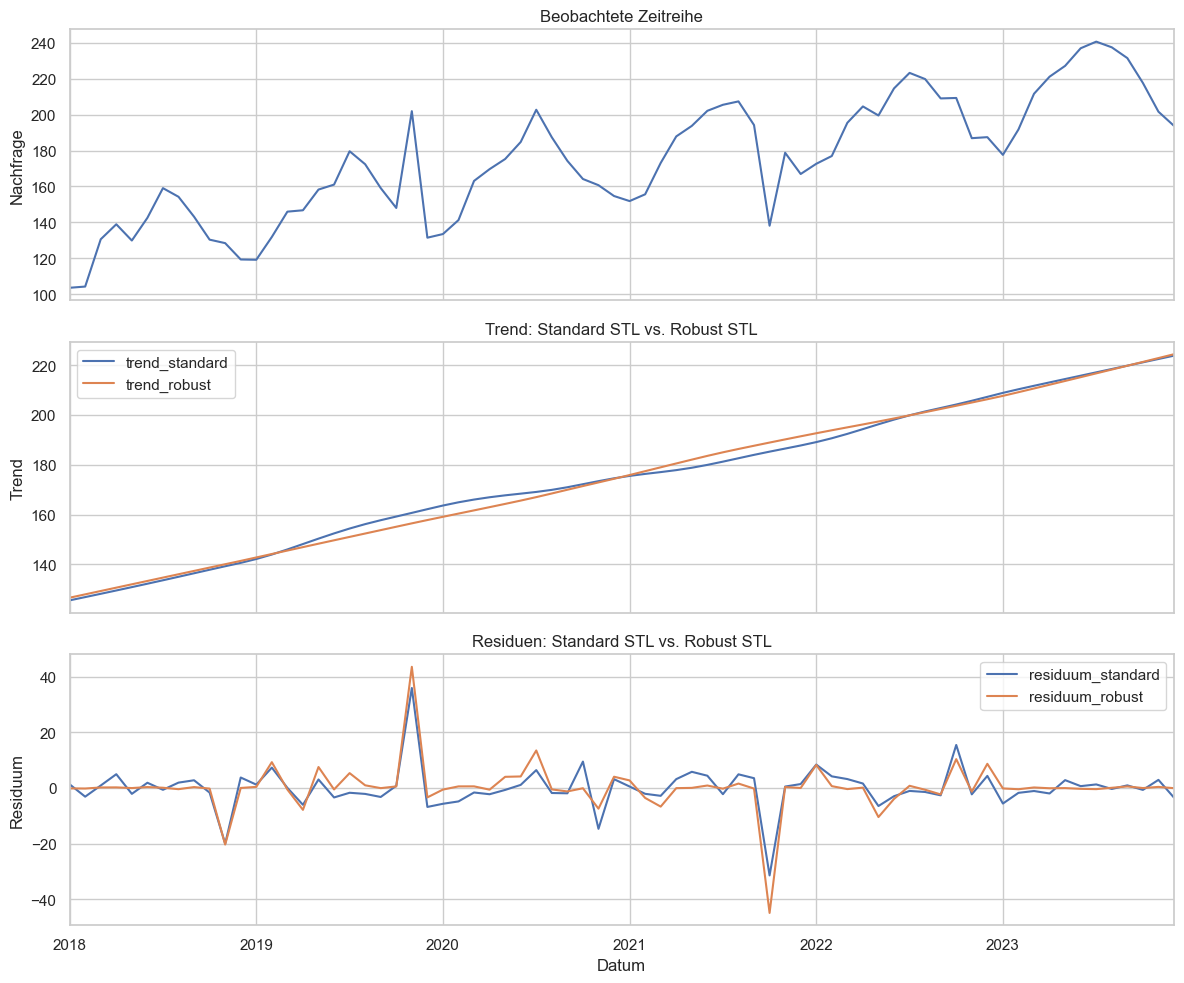

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

comparison["beobachtet"].plot(ax=axes[0], title="Beobachtete Zeitreihe")
axes[0].set_ylabel("Nachfrage")

comparison[["trend_standard", "trend_robust"]].plot(ax=axes[1], title="Trend: Standard STL vs. Robust STL")
axes[1].set_ylabel("Trend")

comparison[["residuum_standard", "residuum_robust"]].plot(ax=axes[2], title="Residuen: Standard STL vs. Robust STL")
axes[2].set_ylabel("Residuum")
axes[2].set_xlabel("Datum")

plt.tight_layout()
plt.show()

In [12]:
vergleich_ausreisser = comparison.loc[comparison["residuum_robust"].abs().nlargest(5).index]
vergleich_ausreisser.sort_index()

,beobachtet,trend_standard,trend_robust,residuum_standard,residuum_robust
2018-11-01,128.396990,139.230748,140.044571,-20.035615,-20.342399
2019-11-01,201.912707,160.665037,156.458176,35.910739,43.528498
2020-07-01,202.708238,169.076589,166.995047,6.403293,13.467071
2021-10-01,138.093443,185.258595,188.906282,-31.433576,-44.925694
2022-05-01,199.514221,196.250495,197.366586,-6.502331,-10.464953


### Interpretation des robusten Vergleichs

Bei starken Sonderereignissen ist robuste STL oft besser geeignet, wenn das Ziel ein stabiles Normalmuster ist.

Standard-STL kann Ausreißer stärker in Trend oder Saison aufnehmen. Robuste STL lässt solche Punkte eher im Residuum sichtbar. Das ist für fachliche Kommunikation hilfreich: Man kann sagen, welche Monate nicht zum normalen Muster passen.

## 7. Bereitstellung: Was würde man mit dem Ergebnis tun?

In einem echten Projekt könnte man die Komponenten nutzen, um:

- saisonbereinigte Nachfrage zu berichten
- auffällige Monate für Ursachenanalyse zu markieren
- ein Prognosemodell auf der saisonbereinigten Reihe aufzubauen
- typische saisonale Faktoren in Planung und Budgetierung zu verwenden

Bereitstellung bedeutet hier nicht zwingend eine produktive Software. Es kann auch ein wiederholbarer Analysebericht, ein Dashboard oder ein dokumentierter Prognoseprozess sein.

## Zusammenfassung

Dieses Notebook hat STL im CRISP-DM-Rahmen erklärt:

- Im Geschäftsverständnis wurde geklärt, welche fachlichen Fragen STL beantworten soll.
- Im Datenverständnis wurde die Zeitreihe visuell und strukturell geprüft.
- In der Datenvorbereitung wurde sichergestellt, dass eine regelmäßige monatliche Reihe vorliegt.
- In der Modellierung wurde zuerst Standard-STL angewendet.
- In der Evaluation wurden Residuen und Ausreißer bewertet.
- Durch Feedback wurde eine zweite Iteration mit robuster STL begründet.

Die wichtigste Idee lautet: STL ist nicht nur eine Formel. STL ist ein Werkzeug, um Zeitreihen fachlich verständlich zu machen und bessere nächste Modellierungsschritte vorzubereiten.